<a href="https://colab.research.google.com/github/Vigneshwarananandan/instacart-market-basket-analysis/blob/main/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 🛒 INSTACART MARKET BASKET ANALYSIS
# Notebook 02 — Feature Engineering
# Author: Vigneshwaran Rajendran
# ============================================================

# 🛒 Instacart Market Basket Analysis
## Notebook 02 — Feature Engineering

**Goal:** Build three feature tables that will feed the XGBoost reorder prediction model.

| Feature Table | Description |
|---|---|
| `user_features` | How each user shops overall |
| `product_features` | How each product performs overall |
| `user_product_features` | How each user interacts with each product |

These three tables are merged in Notebook 04 to create the final training dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gc
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = "/content/drive/MyDrive/instacart/raw/"
SAVE_PATH = "/content/drive/MyDrive/instacart/processed/"

import os
os.makedirs(SAVE_PATH, exist_ok=True)

print("✅ Setup complete")

Mounted at /content/drive


In [3]:
orders = pd.read_csv(DATA_PATH + "orders.csv", dtype={
    "order_id": "int32", "user_id": "int32", "order_number": "int16",
    "order_dow": "int8", "order_hour_of_day": "int8",
    "days_since_prior_order": "float32"
})

order_products_prior = pd.read_csv(DATA_PATH + "order_products__prior.csv", dtype={
    "order_id": "int32", "product_id": "int32",
    "add_to_cart_order": "int16", "reordered": "int8"
})

order_products_train = pd.read_csv(DATA_PATH + "order_products__train.csv", dtype={
    "order_id": "int32", "product_id": "int32",
    "add_to_cart_order": "int16", "reordered": "int8"
})

products = pd.read_csv(DATA_PATH + "products.csv", dtype={
    "product_id": "int32", "aisle_id": "int16", "department_id": "int8"
})

print(f"✅ orders:               {orders.shape[0]:,} rows")
print(f"✅ order_products_prior: {order_products_prior.shape[0]:,} rows")
print(f"✅ order_products_train: {order_products_train.shape[0]:,} rows")
print(f"✅ products:             {products.shape[0]:,} rows")

✅ orders:               3,421,083 rows
✅ order_products_prior: 32,434,489 rows
✅ order_products_train: 1,384,617 rows
✅ products:             49,688 rows


In [4]:
# We only engineer features from PRIOR orders
# Train orders = ground truth labels (will be used in Notebook 04)

prior_with_orders = order_products_prior.merge(
    orders[["order_id", "user_id", "order_number", "order_dow",
            "order_hour_of_day", "days_since_prior_order"]],
    on="order_id"
)

print(f"✅ prior_with_orders shape: {prior_with_orders.shape}")
print(f"   Unique users:    {prior_with_orders['user_id'].nunique():,}")
print(f"   Unique products: {prior_with_orders['product_id'].nunique():,}")
prior_with_orders.head(3)

✅ prior_with_orders shape: (32434489, 9)
   Unique users:    206,209
   Unique products: 49,677


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,3,5,9,8.0
1,2,28985,2,1,202279,3,5,9,8.0
2,2,9327,3,0,202279,3,5,9,8.0


In [5]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 1: USER-LEVEL FEATURES                ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 1: USER-LEVEL FEATURES                ║
╚══════════════════════════════════════════════════╝



In [6]:
print("⚙️  Building user features...")

# Orders per user from orders table
orders_per_user = (
    orders[orders["eval_set"] == "prior"]
    .groupby("user_id")
    .agg(
        user_total_orders       = ("order_id", "count"),
        user_avg_days_between   = ("days_since_prior_order", "mean"),
        user_std_days_between   = ("days_since_prior_order", "std"),
        user_avg_hour           = ("order_hour_of_day", "mean"),
        user_avg_dow            = ("order_dow", "mean"),
    )
    .reset_index()
)

# Basket stats per user
basket_stats = (
    prior_with_orders
    .groupby(["user_id", "order_id"])["product_id"]
    .count()
    .reset_index()
    .rename(columns={"product_id": "basket_size"})
    .groupby("user_id")
    .agg(
        user_avg_basket_size = ("basket_size", "mean"),
        user_max_basket_size = ("basket_size", "max"),
        user_total_products  = ("basket_size", "sum"),
    )
    .reset_index()
)

# Reorder ratio per user
reorder_ratio = (
    prior_with_orders
    .groupby("user_id")["reordered"]
    .mean()
    .reset_index()
    .rename(columns={"reordered": "user_reorder_ratio"})
)

# Unique products ever bought
unique_products = (
    prior_with_orders
    .groupby("user_id")["product_id"]
    .nunique()
    .reset_index()
    .rename(columns={"product_id": "user_unique_products"})
)

# Merge all user features together
user_features = (
    orders_per_user
    .merge(basket_stats,    on="user_id")
    .merge(reorder_ratio,   on="user_id")
    .merge(unique_products, on="user_id")
)

# Derived features
user_features["user_product_reorder_rate"] = (
    user_features["user_total_products"] / user_features["user_unique_products"]
)

print(f"✅ user_features shape: {user_features.shape}")
print(f"   Features per user:  {user_features.shape[1] - 1}")
user_features.head(3)

⚙️  Building user features...
✅ user_features shape: (206209, 12)
   Features per user:  11


,user_id,user_total_orders,user_avg_days_between,user_std_days_between,user_avg_hour,user_avg_dow,user_avg_basket_size,user_max_basket_size,user_total_products,user_reorder_ratio,user_unique_products,user_product_reorder_rate
0,1,10,19.555555,9.395625,10.300000,2.500000,5.900000,9,59,0.694915,18,3.277778
1,2,14,15.230769,9.867065,10.571429,2.142857,13.928571,26,195,0.476923,102,1.911765
2,3,12,12.090909,5.375026,16.416667,1.083333,7.333333,11,88,0.625000,33,2.666667


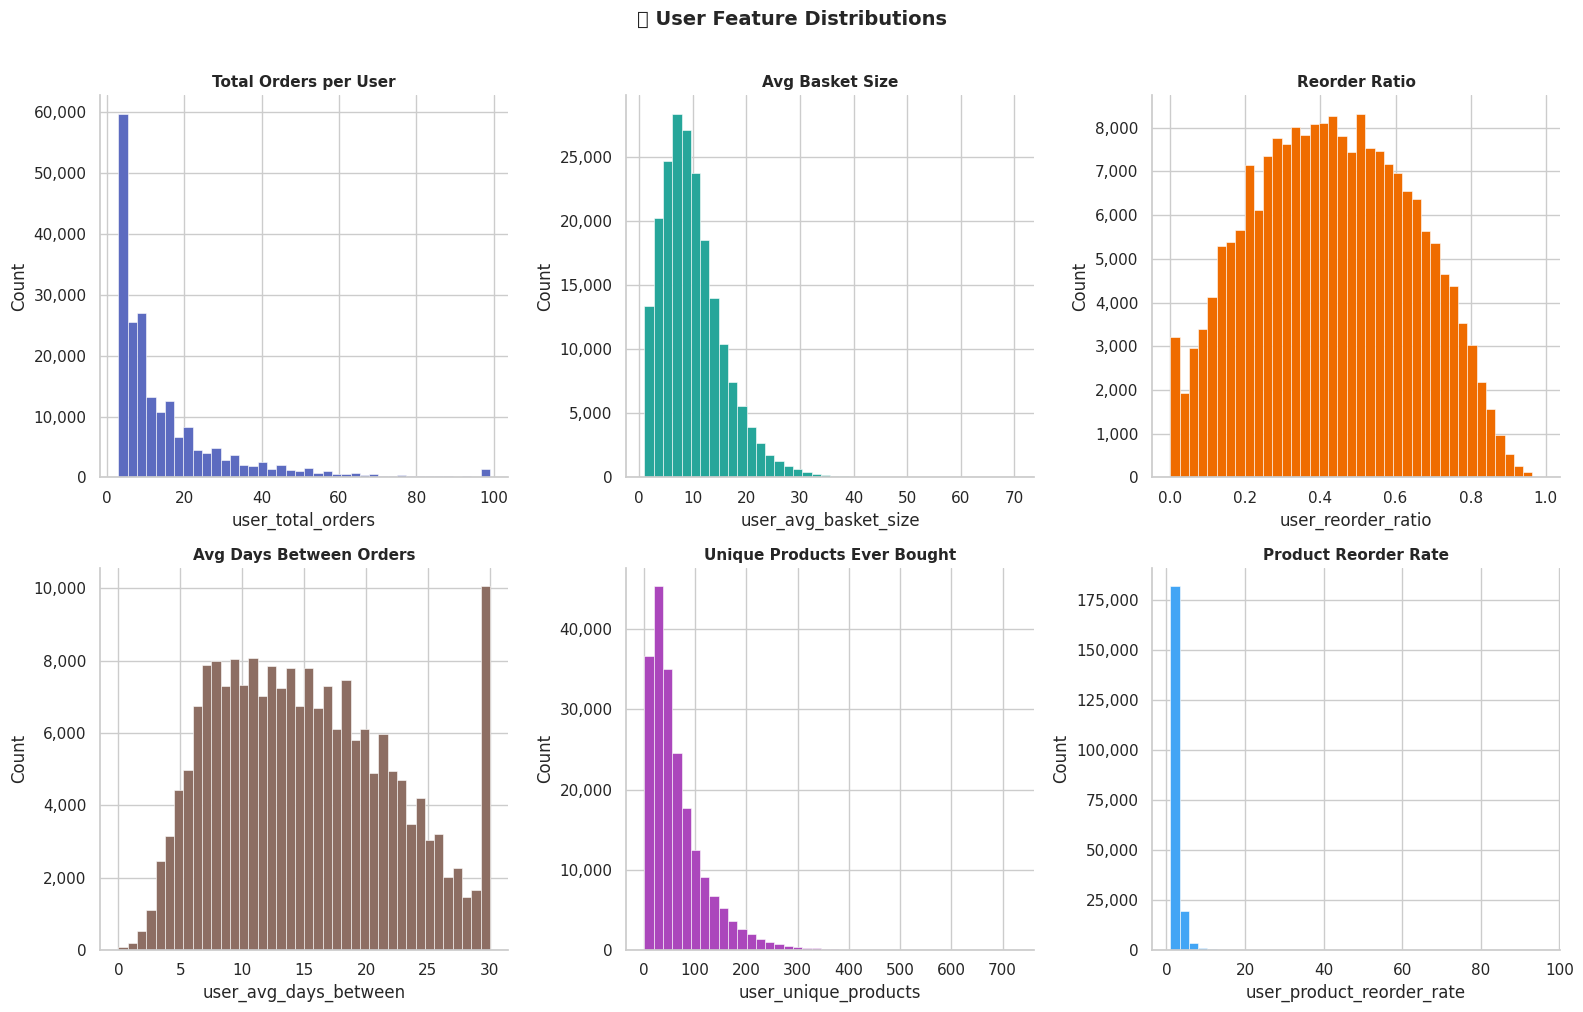

💡 Most users have 5–15 orders. Reorder ratio is approximately normally distributed.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plots = [
    ("user_total_orders",       "Total Orders per User",         "#5C6BC0"),
    ("user_avg_basket_size",    "Avg Basket Size",               "#26A69A"),
    ("user_reorder_ratio",      "Reorder Ratio",                 "#EF6C00"),
    ("user_avg_days_between",   "Avg Days Between Orders",       "#8D6E63"),
    ("user_unique_products",    "Unique Products Ever Bought",   "#AB47BC"),
    ("user_product_reorder_rate","Product Reorder Rate",         "#42A5F5"),
]

for ax, (col, title, color) in zip(axes, plots):
    ax.hist(user_features[col].dropna(), bins=40, color=color,
            edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("👤 User Feature Distributions", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02_user_features_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Most users have 5–15 orders. Reorder ratio is approximately normally distributed.")

In [8]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 2: PRODUCT-LEVEL FEATURES             ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 2: PRODUCT-LEVEL FEATURES             ║
╚══════════════════════════════════════════════════╝



In [9]:
print("⚙️  Building product features...")

product_features = (
    prior_with_orders
    .groupby("product_id")
    .agg(
        product_total_orders        = ("order_id",          "count"),
        product_reorder_rate        = ("reordered",         "mean"),
        product_avg_add_to_cart_pos = ("add_to_cart_order", "mean"),
        product_unique_users        = ("user_id",           "nunique"),
    )
    .reset_index()
)

# How many unique orders contained this product
product_features["product_orders_per_user"] = (
    product_features["product_total_orders"] /
    product_features["product_unique_users"]
)

# Add product name
product_features = product_features.merge(
    products[["product_id", "product_name"]], on="product_id", how="left"
)

print(f"✅ product_features shape: {product_features.shape}")
product_features.head(3)

⚙️  Building product features...
✅ product_features shape: (49677, 7)


,product_id,product_total_orders,product_reorder_rate,product_avg_add_to_cart_pos,product_unique_users,product_orders_per_user,product_name
0,1,1852,0.613391,5.801836,716,2.586592,Chocolate Sandwich Cookies
1,2,90,0.133333,9.888889,78,1.153846,All-Seasons Salt
2,3,277,0.732852,6.415162,74,3.743243,Robust Golden Unsweetened Oolong Tea


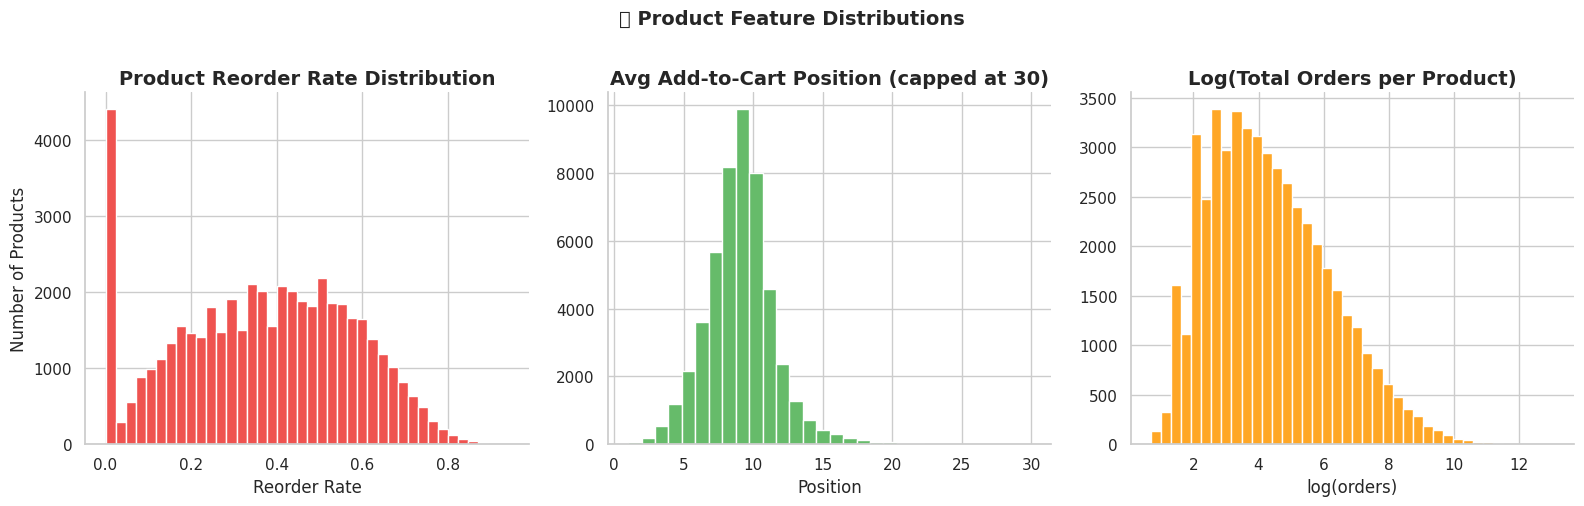


🏆 Top 10 Products by Reorder Rate (min 1,000 orders):
                   product_name  product_reorder_rate  product_total_orders
Half And Half Ultra Pasteurized              0.861691                  2921
     Whole Organic Omega 3 Milk              0.860233                  9108
Organic Lactose Free Whole Milk              0.859030                  8477
 Organic Homogenized Whole Milk              0.857683                  3970
           Ultra-Purified Water              0.857623                  1489
       Milk, Organic, Vitamin D              0.854342                 20198
       Organic Reduced Fat Milk              0.850686                 35663
                      Goat Milk              0.849952                  5185
                         Banana              0.843501                472565
            Organic  Whole Milk              0.841191                  9842


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Reorder rate distribution
axes[0].hist(product_features["product_reorder_rate"], bins=40,
             color="#EF5350", edgecolor="white")
axes[0].set_title("Product Reorder Rate Distribution")
axes[0].set_xlabel("Reorder Rate")
axes[0].set_ylabel("Number of Products")

# Avg cart position distribution
axes[1].hist(product_features["product_avg_add_to_cart_pos"].clip(upper=30),
             bins=30, color="#66BB6A", edgecolor="white")
axes[1].set_title("Avg Add-to-Cart Position (capped at 30)")
axes[1].set_xlabel("Position")

# Log scale — total orders per product
axes[2].hist(np.log1p(product_features["product_total_orders"]),
             bins=40, color="#FFA726", edgecolor="white")
axes[2].set_title("Log(Total Orders per Product)")
axes[2].set_xlabel("log(orders)")

plt.suptitle("📦 Product Feature Distributions", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02_product_features_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 10 by reorder rate (min 1000 orders)
top_reorder = (
    product_features[product_features["product_total_orders"] >= 1000]
    .sort_values("product_reorder_rate", ascending=False)
    .head(10)
)
print("\n🏆 Top 10 Products by Reorder Rate (min 1,000 orders):")
print(top_reorder[["product_name", "product_reorder_rate",
                    "product_total_orders"]].to_string(index=False))

In [11]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 3: USER-PRODUCT INTERACTION FEATURES  ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 3: USER-PRODUCT INTERACTION FEATURES  ║
╚══════════════════════════════════════════════════╝



In [12]:
print("⚙️  Building user-product features... (this takes ~1-2 min on large dataset)")

up_features = (
    prior_with_orders
    .groupby(["user_id", "product_id"])
    .agg(
        up_times_bought             = ("order_id",          "count"),
        up_reorder_rate             = ("reordered",         "mean"),
        up_avg_add_to_cart_pos      = ("add_to_cart_order", "mean"),
        up_last_order_number        = ("order_number",      "max"),
        up_first_order_number       = ("order_number",      "min"),
        up_avg_days_since_prior     = ("days_since_prior_order", "mean"),
    )
    .reset_index()
)

# Add user's total orders to compute "orders since last bought"
up_features = up_features.merge(
    user_features[["user_id", "user_total_orders"]], on="user_id"
)

up_features["up_orders_since_last_bought"] = (
    up_features["user_total_orders"] - up_features["up_last_order_number"]
)

up_features["up_order_rate"] = (
    up_features["up_times_bought"] / up_features["user_total_orders"]
)

# Drop helper column
up_features.drop(columns=["user_total_orders"], inplace=True)

print(f"✅ up_features shape: {up_features.shape}")
print(f"   Unique user-product pairs: {up_features.shape[0]:,}")
up_features.head(3)

⚙️  Building user-product features... (this takes ~1-2 min on large dataset)
✅ up_features shape: (13307953, 10)
   Unique user-product pairs: 13,307,953


,user_id,product_id,up_times_bought,up_reorder_rate,up_avg_add_to_cart_pos,up_last_order_number,up_first_order_number,up_avg_days_since_prior,up_orders_since_last_bought,up_order_rate
0,1,196,10,0.900000,1.400000,10,1,19.555555,0,1.0
1,1,10258,9,0.888889,3.333333,10,2,19.555555,0,0.9
2,1,10326,1,0.000000,5.000000,5,5,28.000000,5,0.1


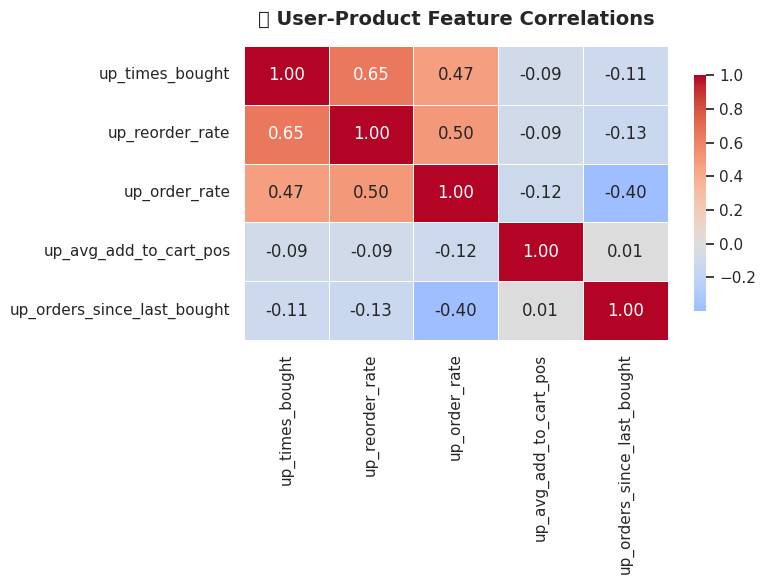

💡 up_times_bought and up_order_rate are highly correlated — expected.


In [13]:
up_sample = up_features.sample(min(50000, len(up_features)),
                                random_state=42)

corr_cols = ["up_times_bought", "up_reorder_rate", "up_order_rate",
             "up_avg_add_to_cart_pos", "up_orders_since_last_bought"]
corr = up_sample[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("🔗 User-Product Feature Correlations", pad=15)
plt.tight_layout()
plt.savefig("02_upfeature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 up_times_bought and up_order_rate are highly correlated — expected.")

In [14]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 4: SAVE FEATURES                      ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 4: SAVE FEATURES                      ║
╚══════════════════════════════════════════════════╝



In [15]:
user_features.to_parquet(SAVE_PATH + "user_features.parquet",    index=False)
product_features.to_parquet(SAVE_PATH + "product_features.parquet", index=False)
up_features.to_parquet(SAVE_PATH + "up_features.parquet",        index=False)

print("✅ Saved all feature tables to Google Drive:")
print(f"   user_features.parquet    → {user_features.shape}")
print(f"   product_features.parquet → {product_features.shape}")
print(f"   up_features.parquet      → {up_features.shape}")

✅ Saved all feature tables to Google Drive:
   user_features.parquet    → (206209, 12)
   product_features.parquet → (49677, 7)
   up_features.parquet      → (13307953, 10)


In [16]:
print("""
╔══════════════════════════════════════════════════════════╗
║   FEATURE ENGINEERING SUMMARY                          ║
╚══════════════════════════════════════════════════════════╝

👤 USER FEATURES (12 features for 206,209 users)
   • user_total_orders         — how many orders the user placed
   • user_avg_days_between     — avg days between orders
   • user_avg_basket_size      — avg products per order
   • user_reorder_ratio        — fraction of items that are reorders
   • user_unique_products      — how many distinct products bought
   • user_product_reorder_rate — avg times each product is reordered

📦 PRODUCT FEATURES (6 features for 49,688 products)
   • product_total_orders       — how many times ordered overall
   • product_reorder_rate       — fraction of orders that are reorders
   • product_avg_add_to_cart_pos — where it usually lands in the cart
   • product_unique_users        — distinct customers who bought it
   • product_orders_per_user     — loyalty metric

🤝 USER-PRODUCT FEATURES (7 features for ~13M pairs)
   • up_times_bought             — how many times user bought this product
   • up_reorder_rate             — user's personal reorder rate for product
   • up_order_rate               — fraction of user orders containing product
   • up_last_order_number        — recency (when did they last buy it?)
   • up_orders_since_last_bought — how many orders ago was it last bought
   • up_avg_add_to_cart_pos      — where user places it in cart

➡️  NEXT: Notebook 03 — Association Rules (FP-Growth Market Basket)
""")


╔══════════════════════════════════════════════════════════╗
║   FEATURE ENGINEERING SUMMARY                          ║
╚══════════════════════════════════════════════════════════╝

👤 USER FEATURES (12 features for 206,209 users)
   • user_total_orders         — how many orders the user placed
   • user_avg_days_between     — avg days between orders
   • user_avg_basket_size      — avg products per order
   • user_reorder_ratio        — fraction of items that are reorders
   • user_unique_products      — how many distinct products bought
   • user_product_reorder_rate — avg times each product is reordered

📦 PRODUCT FEATURES (6 features for 49,688 products)
   • product_total_orders       — how many times ordered overall
   • product_reorder_rate       — fraction of orders that are reorders
   • product_avg_add_to_cart_pos — where it usually lands in the cart
   • product_unique_users        — distinct customers who bought it
   • product_orders_per_user     — loyalty metric

🤝 USER-P